# Task#1: Filtering in the Frequency Domain

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

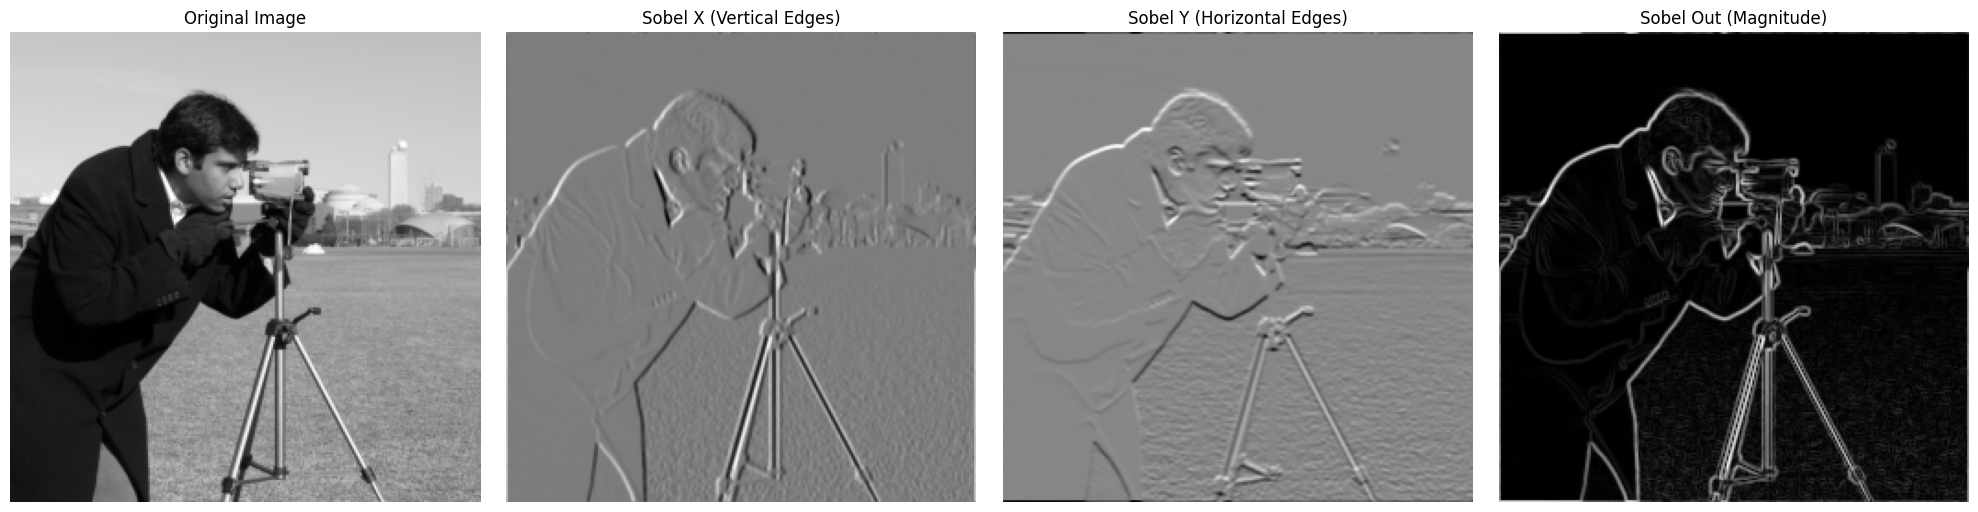

In [8]:
image = data.camera()
image = resize(image, (256, 256))
M, N = image.shape

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Proper padding and centering of kernel in spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    # Find center coordinates
    cy, cx = ph // 2, pw // 2
    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    return np.fft.fft2(np.fft.ifftshift(padded))  # Shift before FFT to place (0,0) at top-left

# Compute FFT of image
F_image = np.fft.fft2(image)

# FFT of centered Sobel filters (use the provided function)
H_x = center_embed_kernel(sobel_x, (M, N))
H_y = center_embed_kernel(sobel_y, (M, N))

# Multiply in the frequency domain
G_x = np.fft.ifft2(F_image * H_x).real
G_y = np.fft.ifft2(F_image * H_y).real

# Compute Gradient Magnitude (sobel magnitude)
sobel_out = np.sqrt(G_x**2 + G_y**2)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image, cmap='gray'); axes[0].set_title('Original Image')
axes[1].imshow(G_x, cmap='gray'); axes[1].set_title('Sobel X (Vertical Edges)')
axes[2].imshow(G_y, cmap='gray'); axes[2].set_title('Sobel Y (Horizontal Edges)')
axes[3].imshow(sobel_out, cmap='gray'); axes[3].set_title('Sobel Out (Magnitude)')

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()